In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd

import networkx as nx
import osmnx as ox

import geopandas as gpd
from shapely.geometry import Point

# -----------------------
# PATHS (EDIT THESE)
# -----------------------
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

GRAPH_PATH = DATA_DIR / "dubai.graphml"
GATES_CSV  = DATA_DIR / "salik_gates.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("GRAPH_PATH exists?", GRAPH_PATH.exists(), GRAPH_PATH)
print("GATES_CSV exists?", GATES_CSV.exists(), GATES_CSV)

# -----------------------
# EXPERIMENT KNOBS (YOU CAN EDIT)
# -----------------------
departure_hours = [8, 14, 18]           # sample hours
vot_grid = [0.2, 0.5, 1.0, 2.0, 4.0, 6.0]  # AED per minute

K_EACH = 3
STOCHASTIC_RUNS = 6
MAX_ROUTES_PER_OD = 30

# Congestion scenarios we will evaluate
SEVERITIES = ["baseline", "mild", "severe"]

# Determinism
GLOBAL_SEED = 7
np.random.seed(GLOBAL_SEED)

print(" Config loaded.")

PROJECT_ROOT: /Users/hussam/Desktop/Folders/salik_optimizer
DATA_DIR: /Users/hussam/Desktop/Folders/salik_optimizer/data
GRAPH_PATH exists? True /Users/hussam/Desktop/Folders/salik_optimizer/data/dubai.graphml
GATES_CSV exists? True /Users/hussam/Desktop/Folders/salik_optimizer/data/salik_gates.csv
 Config loaded.


In [2]:
if not GRAPH_PATH.exists():
    raise FileNotFoundError(f"Graph not found at: {GRAPH_PATH}")

G = ox.load_graphml(GRAPH_PATH)
print("Loaded graph:", type(G), "nodes:", len(G.nodes), "edges:", len(G.edges))

# Ensure travel_time exists
sample_edge = next(iter(G.edges(keys=True, data=True)))
edge_data = sample_edge[3]

if "travel_time" not in edge_data:
    print("Adding edge speeds + travel times...")
    G = ox.add_edge_speeds(G)
    G = ox.add_edge_travel_times(G)
else:
    print("travel_time already present ")

sample_edge2 = next(iter(G.edges(keys=True, data=True)))
print("Edge keys sample:", list(sample_edge2[3].keys())[:15])

Loaded graph: <class 'networkx.classes.multidigraph.MultiDiGraph'> nodes: 61251 edges: 124259
Adding edge speeds + travel times...
Edge keys sample: ['osmid', 'highway', 'junction', 'lanes', 'oneway', 'reversed', 'length', 'geometry', 'speed_kph', 'travel_time']


In [3]:
def restrict_to_largest_component_weak(G_in):
    """
    For directed graphs: keep largest weakly connected component.
    """
    if not nx.is_directed(G_in):
        comps = list(nx.connected_components(G_in))
        largest = max(comps, key=len)
        return G_in.subgraph(largest).copy()
    else:
        comps = list(nx.weakly_connected_components(G_in))
        largest = max(comps, key=len)
        return G_in.subgraph(largest).copy()

G_base = restrict_to_largest_component_weak(G)
print("G_base nodes:", len(G_base.nodes), "edges:", len(G_base.edges))

G_base nodes: 61251 edges: 124259


In [4]:
if not GATES_CSV.exists():
    raise FileNotFoundError(f"Missing gates CSV at: {GATES_CSV}")

gates_df = pd.read_csv(GATES_CSV)

# Standardize col names
col_map = {}
for c in gates_df.columns:
    cl = c.strip().lower()
    if cl in ["latitude", "lat"]:
        col_map[c] = "lat"
    if cl in ["longitude", "lon", "lng"]:
        col_map[c] = "lon"
    if cl in ["name", "gate", "salik", "location"]:
        col_map[c] = "name"
    if cl in ["radius", "radius_m", "radiusmeters", "radius_metres"]:
        col_map[c] = "radius_m"

gates_df = gates_df.rename(columns=col_map)

for r in ["lat", "lon"]:
    if r not in gates_df.columns:
        raise ValueError(f"gates_df missing '{r}'. Columns: {list(gates_df.columns)}")

if "radius_m" not in gates_df.columns:
    gates_df["radius_m"] = 60.0

if "name" not in gates_df.columns:
    gates_df["name"] = [f"Gate{i}" for i in range(len(gates_df))]

print("Loaded gates:", len(gates_df))
display(gates_df.head())

Loaded gates: 10


,name,lat,lon,radius_m
0,Al Barsha,25.116861,55.192619,200
1,Al Safa South,25.178158,55.247000,200
2,Al Safa North,25.193916,55.261795,200
3,Al Garhoud Bridge,25.231067,55.335624,200
4,Al Maktoum Bridge,25.252680,55.321312,200


In [5]:
# Convert edges to GeoDataFrame (with geometry)
edges_gdf = ox.graph_to_gdfs(G_base, nodes=False, fill_edge_geometry=True).reset_index()

# Gate gdf
gates_gdf = gpd.GeoDataFrame(
    gates_df.copy(),
    geometry=[Point(xy) for xy in zip(gates_df["lon"], gates_df["lat"])],
    crs="EPSG:4326"
)

# Project for meter buffers
edges_proj = ox.projection.project_gdf(edges_gdf)
gates_proj = ox.projection.project_gdf(gates_gdf)

# Initialize toll flags
for u, v, k, data in G_base.edges(keys=True, data=True):
    data["is_toll"] = False
    data["toll_gate"] = None

tagged = 0

for _, gate in gates_proj.iterrows():
    buf = gate.geometry.buffer(float(gate["radius_m"]))
    hits = edges_proj[edges_proj.geometry.intersects(buf)]

    gate_name = str(gate["name"])
    for _, row in hits.iterrows():
        u, v, k = row["u"], row["v"], row["key"]
        if G_base.has_edge(u, v, k):
            data = G_base[u][v][k]
            if not data.get("is_toll", False):
                tagged += 1
            data["is_toll"] = True
            if data.get("toll_gate") is None:
                data["toll_gate"] = gate_name

toll_edges = sum(1 for _,_,_,d in G_base.edges(keys=True, data=True) if d.get("is_toll", False))

print("Tagged toll edges:", tagged)
print("Total toll edges in graph:", toll_edges)

Tagged toll edges: 265
Total toll edges in graph: 265


In [6]:
locations = {
    "Marina": (25.0800, 55.1400),
    "JLT": (25.0700, 55.1450),
    "Barsha": (25.1000, 55.2000),
    "Downtown": (25.1972, 55.2744),
    "BusinessBay": (25.1850, 55.2600),
    "DXB": (25.2532, 55.3657),
    "Mirdif": (25.2200, 55.4200),
    "Qusais": (25.2700, 55.3800),
    "Deira": (25.2800, 55.3200),
    "JebelAli": (24.9850, 55.0600),
}

origins = ["Marina", "JLT", "Barsha"]
destinations = ["Downtown", "BusinessBay", "DXB", "Mirdif", "Qusais", "Deira", "JebelAli"]

od_pairs = [(o, d) for o in origins for d in destinations if o != d]
print("Total OD pairs:", len(od_pairs))
od_pairs[:10]

Total OD pairs: 21


[('Marina', 'Downtown'),
 ('Marina', 'BusinessBay'),
 ('Marina', 'DXB'),
 ('Marina', 'Mirdif'),
 ('Marina', 'Qusais'),
 ('Marina', 'Deira'),
 ('Marina', 'JebelAli'),
 ('JLT', 'Downtown'),
 ('JLT', 'BusinessBay'),
 ('JLT', 'DXB')]

In [7]:
def is_peak_hour(hour: int) -> bool:
    return (7 <= hour < 10) or (16 <= hour < 19)

def toll_price_per_gate(hour: int) -> int:
    # your assumption
    return 6 if is_peak_hour(hour) else 4

print("Example gate price at 8:", toll_price_per_gate(8))
print("Example gate price at 14:", toll_price_per_gate(14))

Example gate price at 8: 6
Example gate price at 14: 4


In [8]:
import itertools

def generate_candidate_routes(
    G,
    origin,
    dest,
    k_each=3,
    stochastic_runs=6,
    cap=30,
    diversify_penalty=1.25,
    noise_low=0.90,
    noise_high=1.15,
    seed=0
):
    """
    Returns list of node paths.
    """
    routes = []
    rng = np.random.default_rng(seed)

    # 1) k-shortest simple paths
    try:
        gen = nx.shortest_simple_paths(G, origin, dest, weight="travel_time")
        for r in itertools.islice(gen, k_each):
            routes.append(r)
    except Exception:
        pass

    # 2) penalty rerouting
    G_pen = G.copy()
    for _ in range(k_each):
        try:
            r = nx.shortest_path(G_pen, origin, dest, weight="travel_time")
            routes.append(r)

            for u, v in zip(r[:-1], r[1:]):
                if G_pen.has_edge(u, v):
                    for kk, data in G_pen[u][v].items():
                        tt = data.get("travel_time", None)
                        if tt is not None:
                            data["travel_time"] = float(tt) * diversify_penalty
        except Exception:
            break

    # 3) stochastic travel time perturbations
    # NOTE: we use this only to get diverse ROUTES.
    # We will evaluate congestion deterministically later.
    for _ in range(stochastic_runs):
        G_tmp = G.copy()
        for u, v, k, data in G_tmp.edges(keys=True, data=True):
            tt = data.get("travel_time", None)
            if tt is None:
                continue
            data["travel_time"] = float(tt) * float(rng.uniform(noise_low, noise_high))

        try:
            r = nx.shortest_path(G_tmp, origin, dest, weight="travel_time")
            routes.append(r)
        except Exception:
            continue

    # dedup
    unique = []
    seen = set()
    for r in routes:
        key = tuple(r)
        if key not in seen:
            unique.append(r)
            seen.add(key)

    return unique[:cap]

In [9]:
def edge_best_data(G, u, v, tt_key="travel_time"):
    """
    For MultiDiGraph: choose edge with minimum travel_time.
    """
    data = G.get_edge_data(u, v)
    if not data:
        return None
    best = min(data.values(), key=lambda d: d.get(tt_key, np.inf))
    return best

def route_time_minutes(G, route, tt_key="travel_time"):
    total_sec = 0.0
    for u, v in zip(route[:-1], route[1:]):
        d = edge_best_data(G, u, v, tt_key=tt_key)
        if d is None:
            return None
        total_sec += float(d.get(tt_key, 0.0))
    return total_sec / 60.0

def route_unique_gates(G, route):
    """
     This fixes the big mistake.
    Count UNIQUE gate names encountered along the route.
    """
    gates = set()
    for u, v in zip(route[:-1], route[1:]):
        d = edge_best_data(G, u, v, tt_key="travel_time")
        if d is None:
            continue
        if d.get("is_toll", False):
            gname = d.get("toll_gate", None)
            if gname is not None:
                gates.add(str(gname))
    return gates

def route_toll_aed(G, route, hour):
    gates = route_unique_gates(G, route)
    return len(gates) * toll_price_per_gate(hour), len(gates)

In [10]:
def highway_class(data):
    hw = data.get("highway", None)
    if isinstance(hw, (list, tuple)):
        hw0 = hw[0] if hw else None
    else:
        hw0 = hw
    hw0 = str(hw0).lower() if hw0 is not None else ""
    if ("motorway" in hw0) or ("trunk" in hw0) or ("primary" in hw0):
        return "major"
    return "minor"

def congestion_multiplier(severity: str, hour: int, road_class: str) -> float:
    severity = severity.lower().strip()
    peak = is_peak_hour(hour)

    if severity == "baseline":
        return 1.0

    if severity == "mild":
        if not peak:
            return 1.05 if road_class == "major" else 1.15
        return 1.20 if road_class == "major" else 1.45

    if severity == "severe":
        if not peak:
            return 1.15 if road_class == "major" else 1.35
        return 1.35 if road_class == "major" else 2.00

    raise ValueError("severity must be baseline/mild/severe")

def route_time_minutes_congested(G, route, severity: str, hour: int):
    """
    Compute travel time along a fixed route under congestion multipliers.
    Deterministic: no random noise here.
    """
    total_sec = 0.0
    for u, v in zip(route[:-1], route[1:]):
        d = edge_best_data(G, u, v, tt_key="travel_time")
        if d is None:
            return None
        rc = highway_class(d)
        mult = congestion_multiplier(severity, hour, rc)
        total_sec += float(d.get("travel_time", 0.0)) * mult
    return total_sec / 60.0

print(" Congestion model ready (deterministic).")

 Congestion model ready (deterministic).


In [11]:
route_cache = {}   # (Origin, Destination) -> list_of_routes
routes_rows = []
skipped = []

for (origin_name, dest_name) in od_pairs:
    try:
        o_lat, o_lon = locations[origin_name]
        d_lat, d_lon = locations[dest_name]
        origin_node = ox.nearest_nodes(G_base, o_lon, o_lat)
        dest_node   = ox.nearest_nodes(G_base, d_lon, d_lat)
    except Exception as e:
        skipped.append((origin_name, dest_name, f"nearest_nodes failed: {type(e).__name__}"))
        continue

    key = (origin_name, dest_name)
    if key not in route_cache:
        try:
            routes = generate_candidate_routes(
                G_base, origin_node, dest_node,
                k_each=K_EACH,
                stochastic_runs=STOCHASTIC_RUNS,
                cap=MAX_ROUTES_PER_OD,
                seed=GLOBAL_SEED
            )
            if not routes:
                raise nx.NetworkXNoPath("No routes")
            route_cache[key] = routes
        except Exception as e:
            skipped.append((origin_name, dest_name, f"route gen failed: {type(e).__name__}"))
            continue

    routes = route_cache[key]

    routes_rows.append({
        "Origin": origin_name,
        "Destination": dest_name,
        "origin_node": origin_node,
        "dest_node": dest_node,
        "routes": routes,
        "n_routes": len(routes),
    })

routes_df = pd.DataFrame(routes_rows)

print(" routes_df built:", routes_df.shape)
print("Skipped:", len(skipped))
if skipped:
    print("Sample skipped:", skipped[:5])

display(routes_df.head())

 routes_df built: (21, 6)
Skipped: 0


,Origin,Destination,origin_node,dest_node,routes,n_routes
0,Marina,Downtown,1166275482,10060572257,"[[1166275482, 2063079209, 2063079201, 11662754...",6
1,Marina,BusinessBay,1166275482,3852409880,"[[1166275482, 2063079209, 2063079201, 11662754...",3
2,Marina,DXB,1166275482,9754862868,"[[1166275482, 2063079209, 2063079201, 11662754...",5
3,Marina,Mirdif,1166275482,335689335,"[[1166275482, 2063079209, 2063079201, 11662754...",5
4,Marina,Qusais,1166275482,4952931230,"[[1166275482, 2063079209, 2063079201, 11662754...",7


In [12]:
results_rows = []

for _, r in routes_df.iterrows():
    origin_name = r["Origin"]
    dest_name = r["Destination"]
    routes = r["routes"]

    for hour in departure_hours:
        # precompute tolls once per route (tolls don't depend on severity)
        toll_aed_list = []
        gate_ct_list = []
        for path in routes:
            toll_aed, gate_ct = route_toll_aed(G_base, path, hour)
            toll_aed_list.append(float(toll_aed))
            gate_ct_list.append(int(gate_ct))

        for sev in SEVERITIES:
            times_list = []
            for path in routes:
                tmin = route_time_minutes_congested(G_base, path, sev, hour)
                if tmin is None:
                    tmin = np.nan
                times_list.append(float(tmin))

            results_rows.append({
                "Origin": origin_name,
                "Destination": dest_name,
                "Hour": int(hour),
                "Severity": str(sev),
                "times": times_list,
                "tolls": toll_aed_list,
                "gate_counts": gate_ct_list,
                "n_routes": len(routes),
            })

results_df = pd.DataFrame(results_rows)

print(" results_df:", results_df.shape)
display(results_df.head())

 results_df: (189, 8)


,Origin,Destination,Hour,Severity,times,tolls,gate_counts,n_routes
0,Marina,Downtown,8,baseline,"[14.762863819608414, 14.873359118267071, 16.28...","[12.0, 12.0, 18.0, 12.0, 12.0, 12.0]","[2, 2, 3, 2, 2, 2]",6
1,Marina,Downtown,8,mild,"[18.787999036502878, 18.94821721955793, 20.618...","[12.0, 12.0, 18.0, 12.0, 12.0, 12.0]","[2, 2, 3, 2, 2, 2]",6
2,Marina,Downtown,8,severe,"[22.718528534200583, 22.939519131517898, 24.77...","[12.0, 12.0, 18.0, 12.0, 12.0, 12.0]","[2, 2, 3, 2, 2, 2]",6
3,Marina,Downtown,14,baseline,"[14.762863819608414, 14.873359118267071, 16.28...","[8.0, 8.0, 12.0, 8.0, 8.0, 8.0]","[2, 2, 3, 2, 2, 2]",6
4,Marina,Downtown,14,mild,"[15.930031991777946, 16.057101585235397, 17.53...","[8.0, 8.0, 12.0, 8.0, 8.0, 8.0]","[2, 2, 3, 2, 2, 2]",6


In [13]:
def audit_results(df):
    print("\n--- RESULTS AUDIT ---")
    print("rows:", len(df))
    print("unique OD:", df[["Origin","Destination"]].drop_duplicates().shape[0])
    print("unique hours:", sorted(df["Hour"].unique()))
    print("unique severities:", sorted(df["Severity"].unique()))
    print("avg routes per row:", round(df["n_routes"].mean(), 2))
    # toll sanity
    all_tolls = np.concatenate([np.array(x, dtype=float) for x in df["tolls"].values])
    print("toll min/max:", float(np.nanmin(all_tolls)), float(np.nanmax(all_tolls)))
    # time sanity
    all_times = np.concatenate([np.array(x, dtype=float) for x in df["times"].values])
    print("time min/max:", float(np.nanmin(all_times)), float(np.nanmax(all_times)))
    print("nan time share:", round(np.isnan(all_times).mean()*100, 4), "%")

audit_results(results_df)


--- RESULTS AUDIT ---
rows: 189
unique OD: 21
unique hours: [np.int64(8), np.int64(14), np.int64(18)]
unique severities: ['baseline', 'mild', 'severe']
avg routes per row: 5.48
toll min/max: 0.0 24.0
time min/max: 11.252110317233507 46.00137201565225
nan time share: 0.0 %


In [14]:
# Multi-toll "scenario" = within an OD×hour×severity row, does ANY candidate route have >=2 gates?
def multi_toll_row(gate_counts):
    return (np.max(gate_counts) >= 2)

baseline_rows = results_df[results_df["Severity"]=="baseline"].copy()

baseline_rows["HasMultiTollCandidate"] = baseline_rows["gate_counts"].apply(multi_toll_row)
multi_toll_rate = baseline_rows["HasMultiTollCandidate"].mean() * 100

print(" Multi-toll candidate presence rate (baseline rows only, OD×hour):",
      round(multi_toll_rate, 2), "%")

print("Counts:")
print(baseline_rows["HasMultiTollCandidate"].value_counts())

 Multi-toll candidate presence rate (baseline rows only, OD×hour): 76.19 %
Counts:
HasMultiTollCandidate
True     48
False    15
Name: count, dtype: int64


In [15]:
def choose_best_idx(times, tolls, vot):
    times = np.array(times, dtype=float)
    tolls = np.array(tolls, dtype=float)
    cost = times * vot + tolls
    return int(np.nanargmin(cost))

# Switching definition:
# For each (OD, hour) under baseline, does the chosen toll change as VOT changes?
switch_flags = []

for _, row in baseline_rows.iterrows():
    times = row["times"]
    tolls = row["tolls"]

    chosen_tolls = []
    for v in vot_grid:
        idx = choose_best_idx(times, tolls, v)
        chosen_tolls.append(float(tolls[idx]))

    switch_flags.append(len(set(chosen_tolls)) > 1)

switch_rate = np.mean(switch_flags) * 100
print(" Switch rate (pricing/VOT only, baseline):", round(switch_rate, 2), "%")

 Switch rate (pricing/VOT only, baseline): 57.14 %


In [16]:
# For each OD×hour×VOT: does best toll under baseline differ from best toll under severe?
chg_flags = []

# index for quick pairing
base_map = results_df[results_df["Severity"]=="baseline"].set_index(["Origin","Destination","Hour"])
sev_map  = results_df[results_df["Severity"]=="severe"].set_index(["Origin","Destination","Hour"])

common_keys = base_map.index.intersection(sev_map.index)
print("Common OD×hour keys baseline vs severe:", len(common_keys))

for key in common_keys:
    base_row = base_map.loc[key]
    sev_row  = sev_map.loc[key]

    base_times, base_tolls = base_row["times"], base_row["tolls"]
    sev_times, sev_tolls   = sev_row["times"],  sev_row["tolls"]

    # toll lists should match (tolls depend on gates/hour, not severity)
    # If they don't match, something is wrong.
    if list(base_tolls) != list(sev_tolls):
        raise ValueError(f"Toll mismatch between severities for {key} — check your pipeline.")

    for v in vot_grid:
        i0 = choose_best_idx(base_times, base_tolls, v)
        i1 = choose_best_idx(sev_times, sev_tolls, v)
        chg_flags.append(float(base_tolls[i0]) != float(sev_tolls[i1]))

change_rate = np.mean(chg_flags) * 100 if chg_flags else np.nan
print(" Congestion change rate (baseline vs severe) across OD×hour×VOT:",
      round(change_rate, 2), "%")

Common OD×hour keys baseline vs severe: 63
 Congestion change rate (baseline vs severe) across OD×hour×VOT: 9.79 %


In [17]:
eff_rows = []

# We compute break-even only on baseline (clean story).
for _, row in baseline_rows.iterrows():
    times = np.array(row["times"], dtype=float)
    tolls = np.array(row["tolls"], dtype=float)

    # baseline free route time = fastest route among those with toll=0 (if exists)
    free_mask = (tolls == 0)
    if free_mask.any():
        baseline_free_time = float(np.nanmin(times[free_mask]))
    else:
        baseline_free_time = float(np.nanmin(times))

    for t, c in zip(times, tolls):
        minutes_saved = max(0.0, baseline_free_time - float(t))
        if c > 0 and minutes_saved > 0:
            break_even_vot = float(c) / float(minutes_saved)  # AED/min
            eff_rows.append(break_even_vot)

eff = np.array(eff_rows, dtype=float)

print(" Toll routes with positive savings (baseline):", len(eff))
if len(eff) > 0:
    print("Break-even VOT AED/min:")
    print("  Median:", round(np.median(eff), 3))
    print("  25%:", round(np.quantile(eff, 0.25), 3))
    print("  75%:", round(np.quantile(eff, 0.75), 3))

    print("\nShare of toll routes rational if your VOT ≥ threshold:")
    for thr in [0.3, 0.5, 1, 2, 4, 6]:
        pct = (eff <= thr).mean() * 100
        print(f"  VOT ≥ {thr}: {pct:.2f}%")
else:
    print("No toll routes produced positive time savings in baseline candidate set.")

 Toll routes with positive savings (baseline): 90
Break-even VOT AED/min:
  Median: 2.546
  25%: 1.728
  75%: 6.06

Share of toll routes rational if your VOT ≥ threshold:
  VOT ≥ 0.3: 0.00%
  VOT ≥ 0.5: 0.00%
  VOT ≥ 1: 0.00%
  VOT ≥ 2: 26.67%
  VOT ≥ 4: 65.56%
  VOT ≥ 6: 73.33%


In [18]:
print("========== DENOMINATOR AUDIT ==========\n")

n_od = routes_df[["Origin","Destination"]].drop_duplicates().shape[0]
n_hours = len(departure_hours)
n_vot = len(vot_grid)

print("Unique OD pairs:", n_od)
print("Hours tested:", n_hours)
print("VOT levels:", n_vot)

expected_baseline_rows = n_od * n_hours
actual_baseline_rows = results_df[results_df["Severity"]=="baseline"].shape[0]

print("\nBaseline rows expected:", expected_baseline_rows)
print("Baseline rows actual:", actual_baseline_rows)

# Congestion comparisons
common_keys = results_df[results_df["Severity"]=="baseline"].set_index(
    ["Origin","Destination","Hour"]
).index.intersection(
    results_df[results_df["Severity"]=="severe"].set_index(
        ["Origin","Destination","Hour"]
    ).index
)

print("\nCommon OD×hour keys baseline vs severe:", len(common_keys))
print("Expected total VOT comparisons:", len(common_keys) * n_vot)

print("\n========================================")

========== DENOMINATOR AUDIT ==========

Unique OD pairs: 21
Hours tested: 3
VOT levels: 6

Baseline rows expected: 63
Baseline rows actual: 63

Common OD×hour keys baseline vs severe: 63
Expected total VOT comparisons: 378



In [19]:
change_records = []

base_map = results_df[results_df["Severity"]=="baseline"].set_index(["Origin","Destination","Hour"])
sev_map  = results_df[results_df["Severity"]=="severe"].set_index(["Origin","Destination","Hour"])

for key in common_keys:
    base_row = base_map.loc[key]
    sev_row  = sev_map.loc[key]

    base_times, base_tolls = base_row["times"], base_row["tolls"]
    sev_times, sev_tolls   = sev_row["times"],  sev_row["tolls"]

    for v in vot_grid:
        i0 = choose_best_idx(base_times, base_tolls, v)
        i1 = choose_best_idx(sev_times, sev_tolls, v)

        changed = float(base_tolls[i0]) != float(sev_tolls[i1])

        change_records.append({
            "Origin": key[0],
            "Destination": key[1],
            "Hour": key[2],
            "VOT": v,
            "Changed": changed
        })

chg_df = pd.DataFrame(change_records)

print("Total decisions evaluated:", len(chg_df))
print("Total changed:", chg_df["Changed"].sum())
print("Change rate:", round(chg_df["Changed"].mean()*100,2), "%")

display(chg_df.head())

Total decisions evaluated: 378
Total changed: 37
Change rate: 9.79 %


,Origin,Destination,Hour,VOT,Changed
0,Marina,Downtown,8,0.2,False
1,Marina,Downtown,8,0.5,False
2,Marina,Downtown,8,1.0,False
3,Marina,Downtown,8,2.0,False
4,Marina,Downtown,8,4.0,False


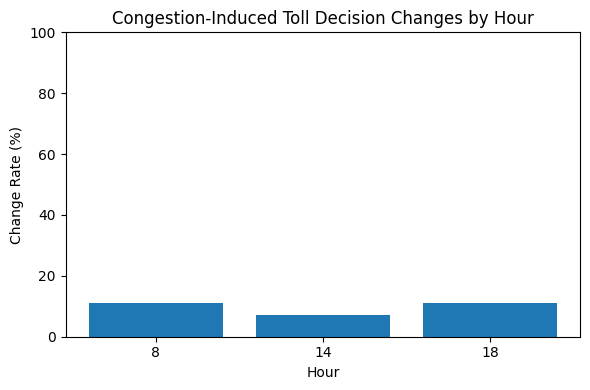

Hour
8     11.111111
14     7.142857
18    11.111111
Name: Changed, dtype: float64


In [20]:
hour_change = chg_df.groupby("Hour")["Changed"].mean()*100

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(hour_change.index.astype(str), hour_change.values)
plt.ylabel("Change Rate (%)")
plt.xlabel("Hour")
plt.title("Congestion-Induced Toll Decision Changes by Hour")
plt.ylim(0,100)
plt.tight_layout()
plt.show()

print(hour_change)

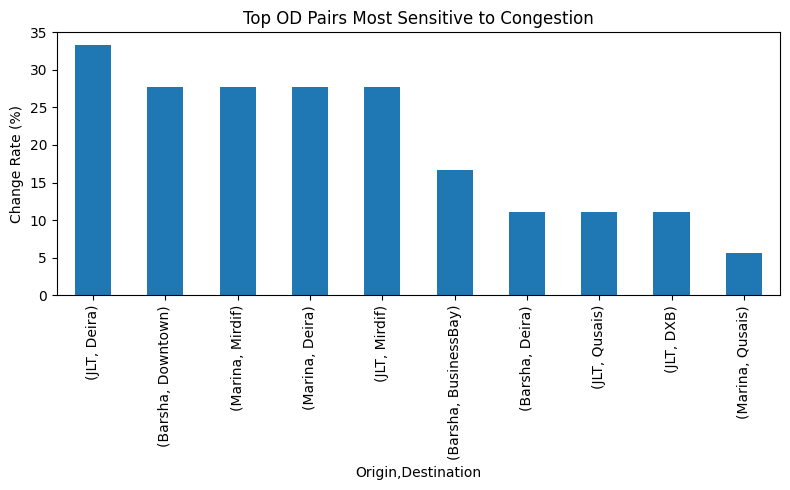

Origin  Destination
JLT     Deira          33.333333
Barsha  Downtown       27.777778
Marina  Mirdif         27.777778
        Deira          27.777778
JLT     Mirdif         27.777778
Barsha  BusinessBay    16.666667
        Deira          11.111111
JLT     Qusais         11.111111
        DXB            11.111111
Marina  Qusais          5.555556
Name: Changed, dtype: float64

In [21]:
od_change = (
    chg_df.groupby(["Origin","Destination"])["Changed"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))
od_change.head(10).plot(kind="bar")
plt.ylabel("Change Rate (%)")
plt.title("Top OD Pairs Most Sensitive to Congestion")
plt.tight_layout()
plt.show()

display(od_change.head(10))

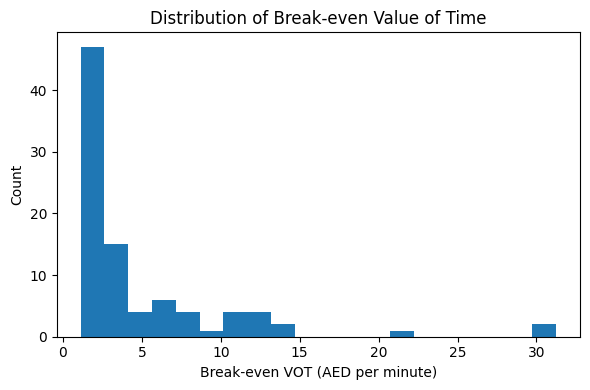

In [22]:
plt.figure(figsize=(6,4))
plt.hist(eff, bins=20)
plt.xlabel("Break-even VOT (AED per minute)")
plt.ylabel("Count")
plt.title("Distribution of Break-even Value of Time")
plt.tight_layout()
plt.show()

In [23]:
multi_opt_flags = []

for _, row in baseline_rows.iterrows():
    times = row["times"]
    tolls = row["tolls"]
    gates = row["gate_counts"]

    # test at high VOT (6 AED/min)
    idx = choose_best_idx(times, tolls, 6.0)

    multi_opt_flags.append(gates[idx] >= 2)

multi_opt_rate = np.mean(multi_opt_flags) * 100

print("Optimal route uses ≥2 gates at VOT=6 in:",
      round(multi_opt_rate,2), "% of baseline OD×hour cases")

Optimal route uses ≥2 gates at VOT=6 in: 66.67 % of baseline OD×hour cases


In [24]:
import numpy as np
import pandas as pd

# ---------------------------------------
# 1️⃣ Identify the OD with highest change
# ---------------------------------------

od_change = (
    chg_df.groupby(["Origin","Destination"])["Changed"]
    .mean()
    .sort_values(ascending=False)
)

top_od = od_change.index[0]
top_rate = od_change.iloc[0] * 100

print("Most congestion-sensitive OD pair:")
print(f"{top_od[0]} → {top_od[1]}")
print(f"Change rate: {round(top_rate,2)}%")
print()

# ---------------------------------------
# 2️⃣ Pull baseline + severe rows
# ---------------------------------------

base_row = base_map.loc[(top_od[0], top_od[1], slice(None))]
sev_row  = sev_map.loc[(top_od[0], top_od[1], slice(None))]

print("Hours analyzed:", list(base_row.index.get_level_values("Hour")))

# ---------------------------------------
# 3️⃣ Compute average congestion inflation
# ---------------------------------------

inflation_records = []

for hour in departure_hours:
    b = base_map.loc[(top_od[0], top_od[1], hour)]
    s = sev_map.loc[(top_od[0], top_od[1], hour)]

    base_times = np.array(b["times"], dtype=float)
    sev_times  = np.array(s["times"], dtype=float)

    inflation = sev_times / base_times
    inflation_records.append({
        "Hour": hour,
        "MeanInflation": np.nanmean(inflation),
        "MaxInflation": np.nanmax(inflation),
        "MinInflation": np.nanmin(inflation)
    })

inflation_df = pd.DataFrame(inflation_records)
print("\nCongestion time inflation ratios (Severe / Baseline):")
display(inflation_df)

# ---------------------------------------
# 4️⃣ Check route composition differences
# ---------------------------------------

def route_minor_share(G, route):
    minor = 0
    total = 0
    for u,v in zip(route[:-1], route[1:]):
        d = edge_best_data(G, u, v)
        if d is None:
            continue
        total += 1
        if highway_class(d) == "minor":
            minor += 1
    return minor / total if total > 0 else 0

composition_rows = []

for hour in departure_hours:
    b = base_map.loc[(top_od[0], top_od[1], hour)]
    routes = routes_df[
        (routes_df["Origin"]==top_od[0]) &
        (routes_df["Destination"]==top_od[1])
    ]["routes"].values[0]

    shares = [route_minor_share(G_base, r) for r in routes]

    composition_rows.append({
        "Hour": hour,
        "AvgMinorShareAcrossRoutes": np.mean(shares),
        "MaxMinorShare": np.max(shares)
    })

composition_df = pd.DataFrame(composition_rows)

print("\nMinor-road exposure:")
display(composition_df)

# ---------------------------------------
# 5️⃣ Which VOT levels caused switching?
# ---------------------------------------

switch_details = chg_df[
    (chg_df["Origin"]==top_od[0]) &
    (chg_df["Destination"]==top_od[1]) &
    (chg_df["Changed"]==True)
]

print("\nVOT levels where congestion changed decision:")
display(switch_details.sort_values(["Hour","VOT"]))

Most congestion-sensitive OD pair:
JLT → Deira
Change rate: 33.33%

Hours analyzed: [8, 14, 18]

Congestion time inflation ratios (Severe / Baseline):


,Hour,MeanInflation,MaxInflation,MinInflation
0,8,1.448257,1.466988,1.440000
1,14,1.180233,1.185996,1.177692
2,18,1.448257,1.466988,1.440000



Minor-road exposure:


,Hour,AvgMinorShareAcrossRoutes,MaxMinorShare
0,8,0.229965,0.294118
1,14,0.229965,0.294118
2,18,0.229965,0.294118



VOT levels where congestion changed decision:


,Origin,Destination,Hour,VOT,Changed
220,JLT,Deira,8,4.0,True
221,JLT,Deira,8,6.0,True
225,JLT,Deira,14,2.0,True
226,JLT,Deira,14,4.0,True
232,JLT,Deira,18,4.0,True
233,JLT,Deira,18,6.0,True


In [25]:
NAVY = "#132F4C"
YELLOW = "#F4B400"

import matplotlib.pyplot as plt
import numpy as np

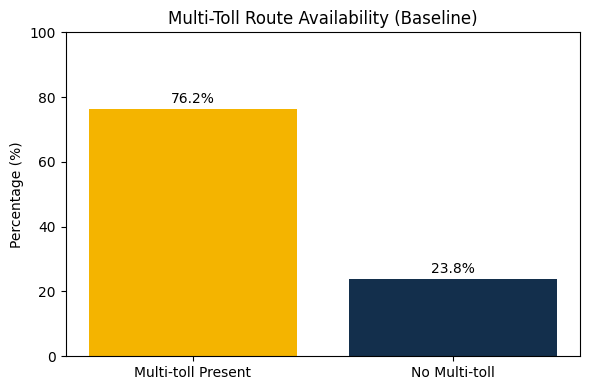

In [26]:
# Data
labels = ["Multi-toll Present", "No Multi-toll"]
values = [76.19, 23.81]

colors = [YELLOW, NAVY]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values, color=colors)

plt.ylabel("Percentage (%)")
plt.title("Multi-Toll Route Availability (Baseline)")
plt.ylim(0,100)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2,
             f"{height:.1f}%", ha='center')

plt.tight_layout()
plt.show()

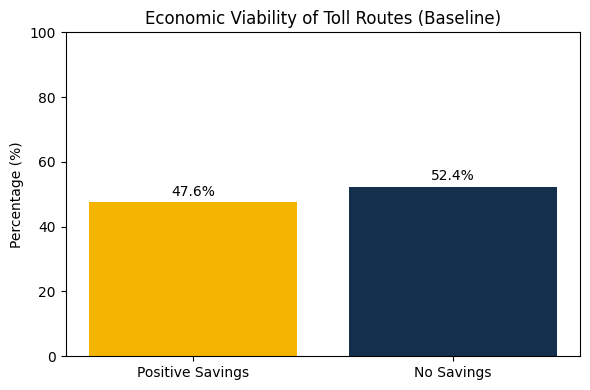

In [27]:
labels = ["Positive Savings", "No Savings"]
values = [47.62, 52.38]

colors = [YELLOW, NAVY]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values, color=colors)

plt.ylabel("Percentage (%)")
plt.title("Economic Viability of Toll Routes (Baseline)")
plt.ylim(0,100)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2,
             f"{height:.1f}%", ha='center')

plt.tight_layout()
plt.show()

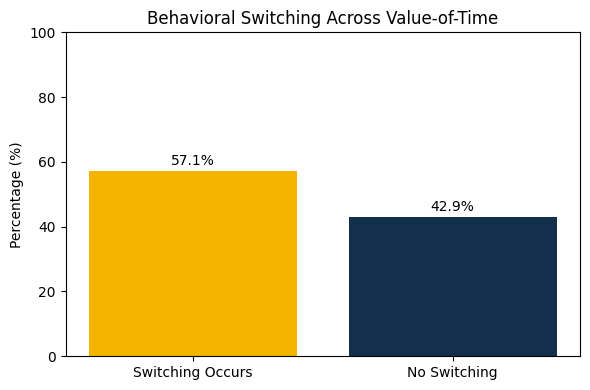

In [28]:
labels = ["Switching Occurs", "No Switching"]
values = [57.14, 42.86]

colors = [YELLOW, NAVY]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values, color=colors)

plt.ylabel("Percentage (%)")
plt.title("Behavioral Switching Across Value-of-Time")
plt.ylim(0,100)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2,
             f"{height:.1f}%", ha='center')

plt.tight_layout()
plt.show()

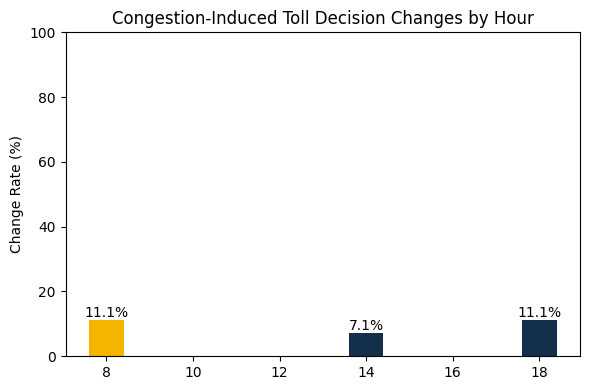

In [29]:
hours = [8, 14, 18]
values = [11.11, 7.14, 11.11]

max_index = np.argmax(values)
colors = [NAVY]*len(values)
colors[max_index] = YELLOW

plt.figure(figsize=(6,4))
bars = plt.bar(hours, values, color=colors)

plt.ylabel("Change Rate (%)")
plt.title("Congestion-Induced Toll Decision Changes by Hour")
plt.ylim(0,100)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
             f"{height:.1f}%", ha='center')

plt.tight_layout()
plt.show()

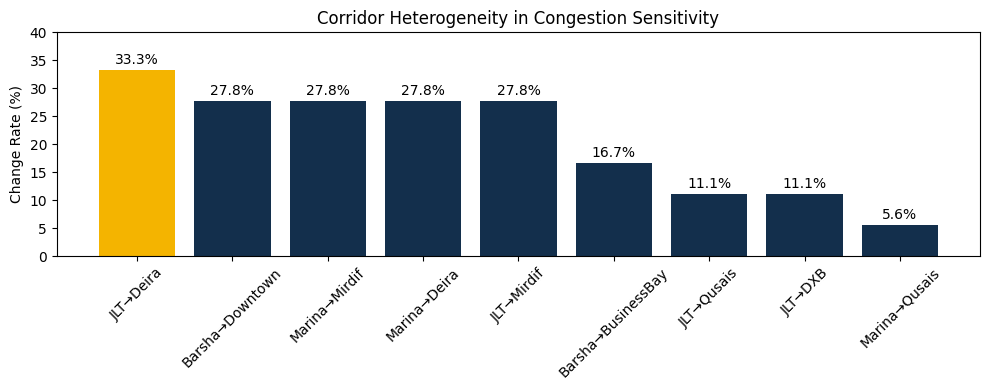

In [30]:
corridors = [
    "JLT→Deira",
    "Barsha→Downtown",
    "Marina→Mirdif",
    "Marina→Deira",
    "JLT→Mirdif",
    "Barsha→BusinessBay",
    "JLT→Qusais",
    "JLT→DXB",
    "Marina→Qusais"
]

values = [33.33,27.78,27.78,27.78,27.78,16.67,11.11,11.11,5.56]

max_index = np.argmax(values)
colors = [NAVY]*len(values)
colors[max_index] = YELLOW

plt.figure(figsize=(10,4))
bars = plt.bar(corridors, values, color=colors)

plt.xticks(rotation=45)
plt.ylabel("Change Rate (%)")
plt.title("Corridor Heterogeneity in Congestion Sensitivity")
plt.ylim(0,40)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
             f"{height:.1f}%", ha='center')

plt.tight_layout()
plt.show()

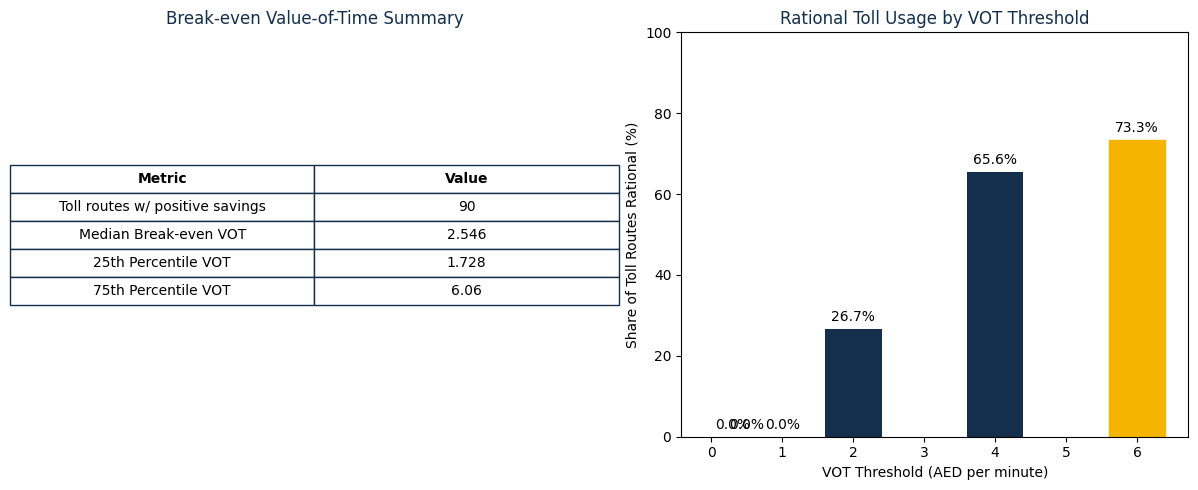

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Brand colors
NAVY = "#132F4C"
YELLOW = "#F4B400"

# ===============================
# DATA
# ===============================

positive_savings = 90

median_vot = 2.546
q25_vot = 1.728
q75_vot = 6.06

vot_thresholds = [0.3, 0.5, 1, 2, 4, 6]
rational_share = [0.00, 0.00, 0.00, 26.67, 65.56, 73.33]

# ===============================
# FIGURE LAYOUT
# ===============================

fig, axs = plt.subplots(1, 2, figsize=(12,5))

# --------------------------------
# LEFT PANEL: Summary Table
# --------------------------------

axs[0].axis("off")

table_data = [
    ["Toll routes w/ positive savings", f"{positive_savings}"],
    ["Median Break-even VOT", f"{median_vot:.3f}"],
    ["25th Percentile VOT", f"{q25_vot:.3f}"],
    ["75th Percentile VOT", f"{q75_vot:.2f}"]
]

table = axs[0].table(
    cellText=table_data,
    colLabels=["Metric", "Value"],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

# Color header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
    cell.set_edgecolor(NAVY)

axs[0].set_title("Break-even Value-of-Time Summary", color=NAVY)

# --------------------------------
# RIGHT PANEL: Threshold Chart
# --------------------------------

bars = axs[1].bar(vot_thresholds, rational_share, color=NAVY)

# Highlight highest threshold
bars[-1].set_color(YELLOW)

axs[1].set_xlabel("VOT Threshold (AED per minute)")
axs[1].set_ylabel("Share of Toll Routes Rational (%)")
axs[1].set_ylim(0,100)
axs[1].set_title("Rational Toll Usage by VOT Threshold", color=NAVY)

for bar in bars:
    height = bar.get_height()
    axs[1].text(bar.get_x() + bar.get_width()/2,
                height + 2,
                f"{height:.1f}%",
                ha='center')

plt.tight_layout()
plt.show()

 Saved: route_avoid_tolls.png
 Saved: route_fastest.png

NORMAL / AVOID: 28.56 min | 0 AED | gates=0
FASTEST:       22.55 min | 42 AED | gates=7

Δ Time (avoid - fastest): 6.01 min
If Δ is small, switch OD pair or increase PENALTY_SECONDS to force a more different 'normal' route.


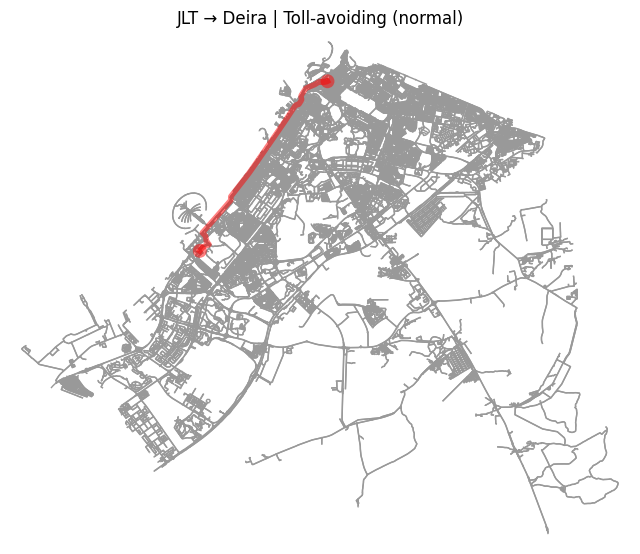

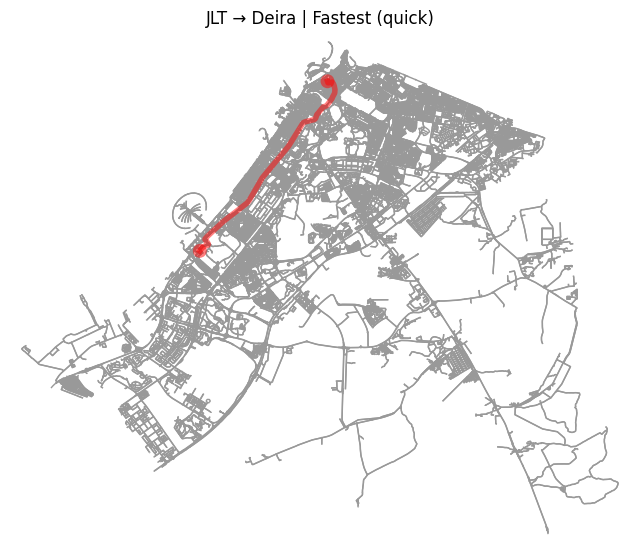

In [32]:
import os
import numpy as np
import networkx as nx
import osmnx as ox

# =========================
# Pick ONE OD pair to visualize
# =========================
ORIGIN_NAME = "JLT"
DEST_NAME   = "Deira"

origin_lat, origin_lon = locations[ORIGIN_NAME]
dest_lat, dest_lon     = locations[DEST_NAME]

origin_node = ox.nearest_nodes(G_base, origin_lon, origin_lat)
dest_node   = ox.nearest_nodes(G_base, dest_lon, dest_lat)

# =========================
# Helper: sum route travel_time (minutes)
# =========================
def route_time_min(G, route, tt_key="travel_time"):
    total_sec = 0.0
    for u, v in zip(route[:-1], route[1:]):
        data = G.get_edge_data(u, v)
        if not data:
            continue
        best = min(data.values(), key=lambda d: d.get(tt_key, np.inf))
        total_sec += float(best.get(tt_key, 0.0))
    return total_sec / 60.0

def route_toll_aed(G, route, hour=8):
    gate_price = toll_price_per_gate(hour)
    gates = 0
    for u, v in zip(route[:-1], route[1:]):
        data = G.get_edge_data(u, v)
        if not data:
            continue
        best = min(data.values(), key=lambda d: d.get("travel_time", np.inf))
        if best.get("is_toll", False):
            gates += 1
    return gates * gate_price, gates

# =========================
# Route 1: "Normal" (toll-avoiding) route
# We create a penalized weight so toll edges become very unattractive.
# =========================
PENALTY_SECONDS = 60 * 60  # 1 hour penalty per toll edge (big enough to avoid if possible)

G_avoid = G_base.copy()
for u, v, k, data in G_avoid.edges(keys=True, data=True):
    tt = float(data.get("travel_time", 0.0))
    if data.get("is_toll", False):
        data["tt_avoid"] = tt + PENALTY_SECONDS
    else:
        data["tt_avoid"] = tt

try:
    route_avoid = nx.shortest_path(G_avoid, origin_node, dest_node, weight="tt_avoid")
except nx.NetworkXNoPath:
    route_avoid = None

# =========================
# Route 2: "Fastest" (time-optimal) route
# =========================
try:
    route_fast = nx.shortest_path(G_base, origin_node, dest_node, weight="travel_time")
except nx.NetworkXNoPath:
    route_fast = None

# =========================
# Plot + Save TWO images (one per route)
# =========================
def save_route_image(G, route, fname, title):
    if route is None:
        print(f"X No route for: {title}")
        return

    fig, ax = ox.plot_graph_route(
        G,
        route,
        route_linewidth=4,
        node_size=0,
        bgcolor="white",
        show=False,
        close=False,
    )
    ax.set_title(title)
    fig.savefig(fname, dpi=220, bbox_inches="tight")
    print(f" Saved: {fname}")

# Save avoid-toll and fastest maps
save_route_image(G_base, route_avoid, "route_avoid_tolls.png", f"{ORIGIN_NAME} → {DEST_NAME} | Toll-avoiding (normal)")
save_route_image(G_base, route_fast,  "route_fastest.png",     f"{ORIGIN_NAME} → {DEST_NAME} | Fastest (quick)")

# =========================
# Quick numeric summary (so you can confirm it's actually quicker)
# =========================
HOUR_FOR_TOLLS = 8  # change 8/14/18 if you want

if route_avoid is not None:
    t_avoid = route_time_min(G_base, route_avoid, "travel_time")
    toll_avoid, gates_avoid = route_toll_aed(G_base, route_avoid, hour=HOUR_FOR_TOLLS)
    print(f"\nNORMAL / AVOID: {t_avoid:.2f} min | {toll_avoid:.0f} AED | gates={gates_avoid}")

if route_fast is not None:
    t_fast = route_time_min(G_base, route_fast, "travel_time")
    toll_fast, gates_fast = route_toll_aed(G_base, route_fast, hour=HOUR_FOR_TOLLS)
    print(f"FASTEST:       {t_fast:.2f} min | {toll_fast:.0f} AED | gates={gates_fast}")

if (route_avoid is not None) and (route_fast is not None):
    print(f"\nΔ Time (avoid - fastest): {t_avoid - t_fast:.2f} min")
    print("If Δ is small, switch OD pair or increase PENALTY_SECONDS to force a more different 'normal' route.")

In [33]:
import numpy as np
import pandas as pd

ml_rows = []

for _, row in results_df.iterrows():

    hour = row["Hour"]
    severity = row["Severity"]

    times = np.array(row["times"], dtype=float)
    tolls = np.array(row["tolls"], dtype=float)

    # identify fastest free route
    free_mask = (tolls == 0)
    if free_mask.any():
        best_free_time = np.nanmin(times[free_mask])
    else:
        best_free_time = np.nanmin(times)

    peak = 1 if (7 <= hour < 10 or 16 <= hour < 19) else 0
    severity_map = {"baseline": 0, "mild": 1, "severe": 2}
    sev_encoded = severity_map[severity]

    for vot in vot_grid:

        cost = times * vot + tolls
        best_idx = int(np.nanargmin(cost))

        chosen_time = float(times[best_idx])
        chosen_toll = float(tolls[best_idx])

        # ---- TRADEOFF FEATURES ----
        time_saved = max(0.0, best_free_time - chosen_time)

        if chosen_toll > 0:
            time_saved_per_aed = time_saved / chosen_toll
        else:
            time_saved_per_aed = 0.0

        uses_toll = 1 if chosen_toll > 0 else 0

        ml_rows.append({
            "VOT": float(vot),
            "PeakHour": peak,
            "Severity": sev_encoded,
            "Time_Saved": time_saved,
            "Time_Saved_Per_AED": time_saved_per_aed,
            "Uses_Toll": uses_toll
        })

ML_df = pd.DataFrame(ml_rows)

print("ML dataset shape:", ML_df.shape)
display(ML_df.head())

ML dataset shape: (1134, 6)


,VOT,PeakHour,Severity,Time_Saved,Time_Saved_Per_AED,Uses_Toll
0,0.2,1,0,0.0,0.0,1
1,0.5,1,0,0.0,0.0,1
2,1.0,1,0,0.0,0.0,1
3,2.0,1,0,0.0,0.0,1
4,4.0,1,0,0.0,0.0,1


In [34]:
from sklearn.model_selection import train_test_split

features = [
    "VOT",
    "PeakHour",
    "Severity",
    "Time_Saved",
    "Time_Saved_Per_AED"
]

X = ML_df[features]
y = ML_df["Uses_Toll"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (850, 5)
Test size: (284, 5)


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("========== LOGISTIC REGRESSION ==========\n")

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print("ROC AUC :", round(roc_auc_score(y_test, y_prob_log), 4))
print()
print(classification_report(y_test, y_pred_log, zero_division=0))


print("\n========== RANDOM FOREST ==========\n")

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("ROC AUC :", round(roc_auc_score(y_test, y_prob_rf), 4))
print()
print(classification_report(y_test, y_pred_rf, zero_division=0))

========== LOGISTIC REGRESSION ==========

Accuracy: 0.6092
ROC AUC : 0.7346

              precision    recall  f1-score   support

           0       0.36      0.85      0.50        66
           1       0.92      0.54      0.68       218

    accuracy                           0.61       284
   macro avg       0.64      0.69      0.59       284
weighted avg       0.79      0.61      0.64       284


========== RANDOM FOREST ==========

Accuracy: 0.6197
ROC AUC : 0.6639

              precision    recall  f1-score   support

           0       0.36      0.80      0.50        66
           1       0.90      0.56      0.69       218

    accuracy                           0.62       284
   macro avg       0.63      0.68      0.60       284
weighted avg       0.78      0.62      0.65       284



In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))
print()
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.6197
ROC AUC: 0.6639

              precision    recall  f1-score   support

           0       0.36      0.80      0.50        66
           1       0.90      0.56      0.69       218

    accuracy                           0.62       284
   macro avg       0.63      0.68      0.60       284
weighted avg       0.78      0.62      0.65       284



In [37]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("Random Forest Feature Importance:")
display(rf_importance)

Random Forest Feature Importance:


VOT                   0.572162
Time_Saved            0.140039
Time_Saved_Per_AED    0.139386
Severity              0.104324
PeakHour              0.044090
dtype: float64

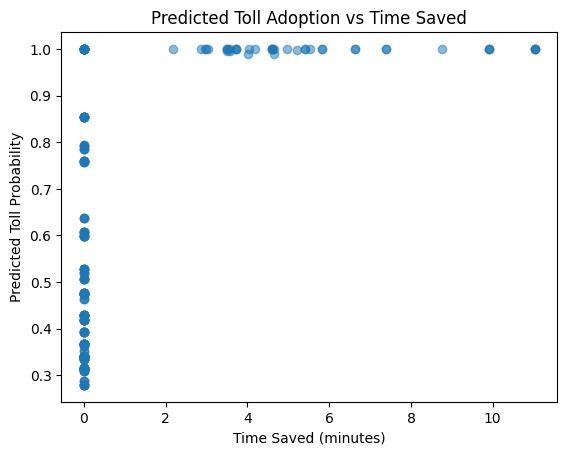

In [38]:
import matplotlib.pyplot as plt

plt.scatter(X_test["Time_Saved"], y_prob_rf, alpha=0.5)
plt.xlabel("Time Saved (minutes)")
plt.ylabel("Predicted Toll Probability")
plt.title("Predicted Toll Adoption vs Time Saved")
plt.show()

In [39]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(log_model, X, y, cv=5, scoring='roc_auc')
print("5-Fold CV AUC:", cv_scores.mean())

5-Fold CV AUC: 0.7222465556564451


In [40]:
import numpy as np
import pandas as pd

ml_rows = []

severity_map = {"baseline": 0, "mild": 1, "severe": 2}

for _, row in results_df.iterrows():
    origin = row["Origin"]
    dest = row["Destination"]
    hour = int(row["Hour"])
    severity = row["Severity"]

    times = np.array(row["times"], dtype=float)
    tolls = np.array(row["tolls"], dtype=float)

    # Best free time (baseline comparator inside this scenario)
    free_mask = (tolls == 0)
    best_free_time = np.nanmin(times[free_mask]) if free_mask.any() else np.nanmin(times)

    peak = 1 if ((7 <= hour < 10) or (16 <= hour < 19)) else 0
    sev_encoded = severity_map[str(severity)]

    for vot in vot_grid:
        cost = times * float(vot) + tolls
        best_idx = int(np.nanargmin(cost))

        chosen_time = float(times[best_idx])
        chosen_toll = float(tolls[best_idx])

        time_saved = max(0.0, float(best_free_time) - chosen_time)
        time_saved_per_aed = (time_saved / chosen_toll) if chosen_toll > 0 else 0.0
        uses_toll = 1 if chosen_toll > 0 else 0

        ml_rows.append({
            # grouping keys (for leakage-safe CV)
            "Origin": origin,
            "Destination": dest,
            "Hour": hour,
            "Group_ODH": f"{origin}->{dest}@{hour}",

            # features
            "VOT": float(vot),
            "PeakHour": peak,
            "Severity": sev_encoded,
            "Time_Saved": time_saved,
            "Time_Saved_Per_AED": time_saved_per_aed,

            # target
            "Uses_Toll": uses_toll
        })

ML_df = pd.DataFrame(ml_rows)
print("ML dataset shape:", ML_df.shape)
display(ML_df.head())

ML dataset shape: (1134, 10)


,Origin,Destination,Hour,Group_ODH,VOT,PeakHour,Severity,Time_Saved,Time_Saved_Per_AED,Uses_Toll
0,Marina,Downtown,8,Marina->Downtown@8,0.2,1,0,0.0,0.0,1
1,Marina,Downtown,8,Marina->Downtown@8,0.5,1,0,0.0,0.0,1
2,Marina,Downtown,8,Marina->Downtown@8,1.0,1,0,0.0,0.0,1
3,Marina,Downtown,8,Marina->Downtown@8,2.0,1,0,0.0,0.0,1
4,Marina,Downtown,8,Marina->Downtown@8,4.0,1,0,0.0,0.0,1


Group 5-Fold CV AUC
  LR mean=0.691  std=0.038
  RF mean=0.675  std=0.051

Single-fold reports (threshold=0.5)

--- Logistic Regression ---
AUC: 0.6907141822396059
              precision    recall  f1-score   support

           0       0.29      0.92      0.44        39
           1       0.97      0.50      0.66       177

    accuracy                           0.58       216
   macro avg       0.63      0.71      0.55       216
weighted avg       0.85      0.58      0.62       216


--- Random Forest ---
AUC: 0.6792698826597132
              precision    recall  f1-score   support

           0       0.30      0.97      0.46        39
           1       0.99      0.50      0.67       177

    accuracy                           0.59       216
   macro avg       0.65      0.74      0.56       216
weighted avg       0.86      0.59      0.63       216



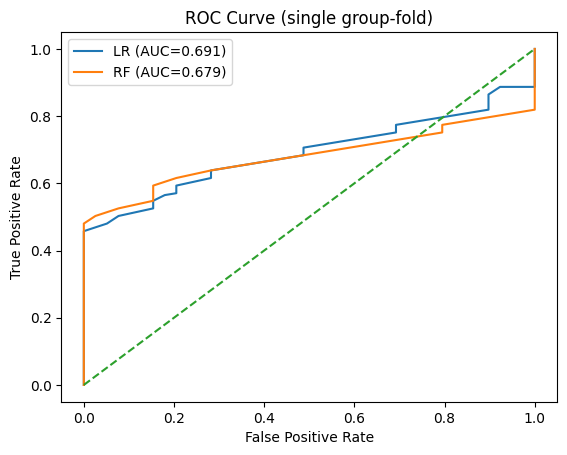

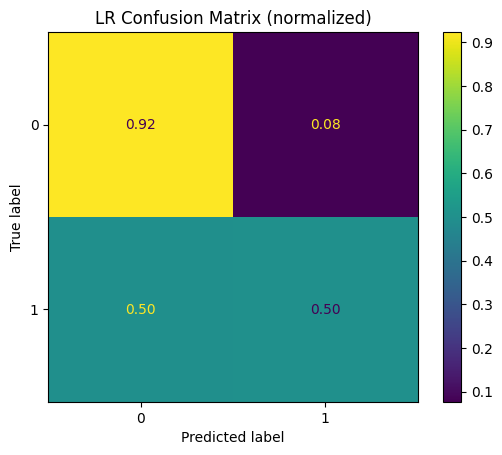

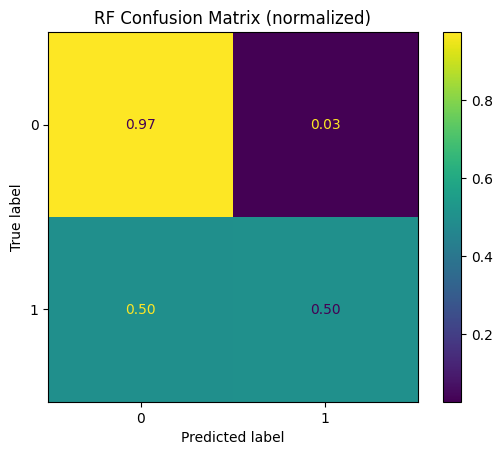

In [41]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

features = ["VOT","PeakHour","Severity","Time_Saved","Time_Saved_Per_AED"]
X = ML_df[features]
y = ML_df["Uses_Toll"].astype(int)
groups = ML_df["Group_ODH"]

# Models (LR scaled, RF not)
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

gkf = GroupKFold(n_splits=5)

# 5-fold group CV AUC
lr_cv = cross_val_score(lr, X, y, cv=gkf, groups=groups, scoring="roc_auc")
rf_cv = cross_val_score(rf, X, y, cv=gkf, groups=groups, scoring="roc_auc")

print("Group 5-Fold CV AUC")
print(f"  LR mean={lr_cv.mean():.3f}  std={lr_cv.std():.3f}")
print(f"  RF mean={rf_cv.mean():.3f}  std={rf_cv.std():.3f}")

# Fit once to show ROC + confusion matrix on a single fold (last fold)
train_idx, test_idx = list(gkf.split(X, y, groups))[-1]
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

lr_prob = lr.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]
lr_pred = (lr_prob >= 0.5).astype(int)
rf_pred = (rf_prob >= 0.5).astype(int)

print("\nSingle-fold reports (threshold=0.5)")
print("\n--- Logistic Regression ---")
print("AUC:", roc_auc_score(y_test, lr_prob))
print(classification_report(y_test, lr_pred, zero_division=0))

print("\n--- Random Forest ---")
print("AUC:", roc_auc_score(y_test, rf_prob))
print(classification_report(y_test, rf_pred, zero_division=0))

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC={roc_auc_score(y_test, lr_prob):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={roc_auc_score(y_test, rf_prob):.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (single group-fold)")
plt.legend()
plt.show()

# Confusion matrices (normalized)
cm_lr = confusion_matrix(y_test, lr_pred, normalize="true")
cm_rf = confusion_matrix(y_test, rf_pred, normalize="true")

ConfusionMatrixDisplay(cm_lr).plot(values_format=".2f")
plt.title("LR Confusion Matrix (normalized)")
plt.show()

ConfusionMatrixDisplay(cm_rf).plot(values_format=".2f")
plt.title("RF Confusion Matrix (normalized)")
plt.show()

In [42]:
def band(p):
    if p < 0.35:
        return "LOW (show free)"
    if p > 0.65:
        return "HIGH (show fastest)"
    return "MID (show in-between)"

band_counts = pd.Series([band(p) for p in lr_prob]).value_counts(normalize=True) * 100
print("Band share (single fold, LR probs):")
display(band_counts.round(2))

Band share (single fold, LR probs):


MID (show in-between)    40.28
HIGH (show fastest)      33.80
LOW (show free)          25.93
Name: proportion, dtype: float64

In [43]:
import numpy as np
import pandas as pd

def route_bucket(toll):
    # customize if you want: "moderate" = 1 gate only
    if toll == 0:
        return "FREE"
    if toll <= 6:      # usually 1 gate at off-peak/peak depending on your fee
        return "MODERATE"
    return "HIGH"

def best_in_bucket(times, tolls, vot, bucket_name):
    times = np.array(times, dtype=float)
    tolls = np.array(tolls, dtype=float)

    idxs = [i for i,(t) in enumerate(tolls) if route_bucket(t) == bucket_name]
    if not idxs:
        return None

    costs = [(times[i]*vot + tolls[i], i) for i in idxs]
    return min(costs, key=lambda x: x[0])  # (cost, idx)

def best_over_buckets(times, tolls, vot, bucket_list):
    best = None
    for b in bucket_list:
        cand = best_in_bucket(times, tolls, vot, b)
        if cand is None:
            continue
        if (best is None) or (cand[0] < best[0]):
            best = cand
    return best  # (cost, idx) or None

baseline_rows = results_df[results_df["Severity"]=="baseline"].copy()

records = []
for _, row in baseline_rows.iterrows():
    times = row["times"]
    tolls = row["tolls"]

    # need at least one moderate route for the argument
    has_mod = any(route_bucket(t) == "MODERATE" for t in tolls)
    has_free = any(route_bucket(t) == "FREE" for t in tolls)
    has_high = any(route_bucket(t) == "HIGH" for t in tolls)

    for vot in vot_grid:
        # Binary menu: FREE vs FASTEST (which usually ends up being HIGH sometimes)
        # We'll define binary as best of {FREE, HIGH} (if HIGH exists) else {FREE, MODERATE}
        binary_buckets = []
        if has_free: binary_buckets.append("FREE")
        if has_high: binary_buckets.append("HIGH")
        elif has_mod: binary_buckets.append("MODERATE")

        tri_buckets = []
        if has_free: tri_buckets.append("FREE")
        if has_mod: tri_buckets.append("MODERATE")
        if has_high: tri_buckets.append("HIGH")

        b_best = best_over_buckets(times, tolls, vot, binary_buckets)
        t_best = best_over_buckets(times, tolls, vot, tri_buckets)

        if b_best is None or t_best is None:
            continue

        b_cost, b_i = b_best
        t_cost, t_i = t_best

        b_toll = float(tolls[b_i])
        t_toll = float(tolls[t_i])

        records.append({
            "Origin": row["Origin"],
            "Destination": row["Destination"],
            "Hour": row["Hour"],
            "VOT": vot,
            "HasModerate": has_mod,
            "TriChosenBucket": route_bucket(t_toll),
            "BinaryToll": b_toll,
            "TriToll": t_toll,
            "Regret_Cost": float(b_cost - t_cost)  # >0 means tri beats binary
        })

cmp_df = pd.DataFrame(records)

# 1) Middle-option win rate: among scenarios where a moderate option exists
mid_win = cmp_df[cmp_df["HasModerate"]].copy()
mid_win_rate = (mid_win["TriChosenBucket"] == "MODERATE").mean() * 100 if len(mid_win) else np.nan

# 2) Binary vs tri improvement
improve_rate = (cmp_df["Regret_Cost"] > 1e-9).mean() * 100
avg_regret = cmp_df["Regret_Cost"].clip(lower=0).mean()

print("MIDDLE-OPTION WIN RATE (when moderate exists):", round(mid_win_rate, 2), "%")
print("TRI beats BINARY (% of decisions):", round(improve_rate, 2), "%")
print("Avg positive regret (AED-equivalent generalized cost):", round(avg_regret, 4))

display(cmp_df.head())

MIDDLE-OPTION WIN RATE (when moderate exists): 65.08 %
TRI beats BINARY (% of decisions): 5.56 %
Avg positive regret (AED-equivalent generalized cost): 0.2807


,Origin,Destination,Hour,VOT,HasModerate,TriChosenBucket,BinaryToll,TriToll,Regret_Cost
0,Marina,Downtown,8,0.2,False,HIGH,12.0,12.0,0.0
1,Marina,Downtown,8,0.5,False,HIGH,12.0,12.0,0.0
2,Marina,Downtown,8,1.0,False,HIGH,12.0,12.0,0.0
3,Marina,Downtown,8,2.0,False,HIGH,12.0,12.0,0.0
4,Marina,Downtown,8,4.0,False,HIGH,12.0,12.0,0.0


In [44]:
print("len(y_test):", len(y_test))

print("len(y_prob_log):", len(y_prob_log) if "y_prob_log" in globals() else "missing")
print("len(y_prob_rf):",  len(y_prob_rf)  if "y_prob_rf"  in globals() else "missing")

print("X_test shape:", X_test.shape if "X_test" in globals() else "missing")

len(y_test): 216
len(y_prob_log): 284
len(y_prob_rf): 284
X_test shape: (216, 5)


In [45]:
# Recompute probabilities so they're guaranteed aligned with the CURRENT X_test / y_test
y_prob_log = log_model.predict_proba(X_test)[:, 1]
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]

print("Aligned lengths now:")
print("len(y_test):", len(y_test))
print("len(y_prob_log):", len(y_prob_log))
print("len(y_prob_rf):", len(y_prob_rf))

Aligned lengths now:
len(y_test): 216
len(y_prob_log): 216
len(y_prob_rf): 216


In [46]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

def find_best_thresholds(y_true, y_prob):
    """
    Returns:
      - best_thr_f1: threshold maximizing F1
      - best_thr_j : threshold maximizing Youden's J (TPR - FPR)
      - df: table of metrics over thresholds (ROC thresholds)
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    # --- Youden's J from ROC ---
    fpr, tpr, roc_thrs = roc_curve(y_true, y_prob)
    J = tpr - fpr
    best_thr_j = float(roc_thrs[np.argmax(J)])

    # --- Best F1 from PR curve ---
    prec, rec, pr_thrs = precision_recall_curve(y_true, y_prob)
    # pr_thrs aligns with prec[:-1], rec[:-1]
    f1s = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-12)
    best_thr_f1 = float(pr_thrs[np.argmax(f1s)])

    # --- Build summary table over ROC thresholds ---
    rows = []
    for thr in roc_thrs:
        y_hat = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_hat, labels=[0,1]).ravel()

        precision = tp / (tp + fp + 1e-12)
        recall    = tp / (tp + fn + 1e-12)
        f1        = 2 * precision * recall / (precision + recall + 1e-12)
        spec      = tn / (tn + fp + 1e-12)
        youden_j  = recall + spec - 1  # same as TPR - FPR

        rows.append([thr, precision, recall, f1, spec, youden_j])

    df = pd.DataFrame(rows, columns=["threshold","precision","recall","f1","specificity","youden_j"])

    return best_thr_f1, best_thr_j, df


def eval_at_threshold(y_true, y_prob, thr, label="Model"):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_hat  = (y_prob >= thr).astype(int)

    print(f"\n===== {label} @ threshold={thr:.4f} =====")
    print(classification_report(y_true, y_hat, zero_division=0))
    print("Confusion Matrix [[TN FP],[FN TP]]:")
    print(confusion_matrix(y_true, y_hat, labels=[0,1]))
    return y_hat

In [47]:
# assumes you already have: y_test, y_prob_log
thr_f1_lr, thr_j_lr, lr_thr_table = find_best_thresholds(y_test, y_prob_log)

print("LR AUC:", round(roc_auc_score(y_test, y_prob_log), 4))
print("LR Avg Precision:", round(average_precision_score(y_test, y_prob_log), 4))
print("Best threshold (F1):", round(thr_f1_lr, 4))
print("Best threshold (Youden J):", round(thr_j_lr, 4))

eval_at_threshold(y_test, y_prob_log, thr_f1_lr, label="LogReg (Best F1)")
eval_at_threshold(y_test, y_prob_log, thr_j_lr,  label="LogReg (Best Youden J)")

# Optional: see top threshold rows
lr_thr_table.sort_values("f1", ascending=False).head(10)

LR AUC: 0.8079
LR Avg Precision: 0.9534
Best threshold (F1): 0.2438
Best threshold (Youden J): 0.4266

===== LogReg (Best F1) @ threshold=0.2438 =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        39
           1       0.82      1.00      0.90       177

    accuracy                           0.82       216
   macro avg       0.41      0.50      0.45       216
weighted avg       0.67      0.82      0.74       216

Confusion Matrix [[TN FP],[FN TP]]:
[[  0  39]
 [  0 177]]

===== LogReg (Best Youden J) @ threshold=0.4266 =====
              precision    recall  f1-score   support

           0       0.36      0.87      0.51        39
           1       0.96      0.66      0.78       177

    accuracy                           0.70       216
   macro avg       0.66      0.77      0.65       216
weighted avg       0.85      0.70      0.73       216

Confusion Matrix [[TN FP],[FN TP]]:
[[ 34   5]
 [ 60 117]]


,threshold,precision,recall,f1,specificity,youden_j
21,0.243766,0.819444,1.000000,0.900763,0.000000,-5.662137e-15
20,0.287037,0.845000,0.954802,0.896552,0.205128,1.599305e-01
19,0.292477,0.841837,0.932203,0.884718,0.205128,1.373316e-01
18,0.315860,0.856383,0.909605,0.882192,0.307692,2.172968e-01
17,0.317145,0.853261,0.887006,0.869806,0.307692,1.946980e-01
16,0.340501,0.886905,0.841808,0.863768,0.512821,3.546284e-01
15,0.346462,0.884146,0.819209,0.850440,0.512821,3.320296e-01
14,0.367118,0.903846,0.796610,0.846847,0.615385,4.119948e-01
13,0.373281,0.898649,0.751412,0.818462,0.615385,3.667970e-01
12,0.378088,0.914894,0.728814,0.811321,0.692308,4.211213e-01


In [48]:
# assumes you already have: y_test, y_prob_rf
thr_f1_rf, thr_j_rf, rf_thr_table = find_best_thresholds(y_test, y_prob_rf)

print("RF AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))
print("RF Avg Precision:", round(average_precision_score(y_test, y_prob_rf), 4))
print("Best threshold (F1):", round(thr_f1_rf, 4))
print("Best threshold (Youden J):", round(thr_j_rf, 4))

eval_at_threshold(y_test, y_prob_rf, thr_f1_rf, label="RF (Best F1)")
eval_at_threshold(y_test, y_prob_rf, thr_j_rf,  label="RF (Best Youden J)")

rf_thr_table.sort_values("f1", ascending=False).head(10)

RF AUC: 0.7963
RF Avg Precision: 0.9523
Best threshold (F1): 0.2796
Best threshold (Youden J): 0.4633

===== RF (Best F1) @ threshold=0.2796 =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        39
           1       0.82      1.00      0.90       177

    accuracy                           0.82       216
   macro avg       0.41      0.50      0.45       216
weighted avg       0.67      0.82      0.74       216

Confusion Matrix [[TN FP],[FN TP]]:
[[  0  39]
 [  0 177]]

===== RF (Best Youden J) @ threshold=0.4633 =====
              precision    recall  f1-score   support

           0       0.36      0.92      0.52        39
           1       0.97      0.64      0.77       177

    accuracy                           0.69       216
   macro avg       0.67      0.78      0.64       216
weighted avg       0.86      0.69      0.73       216

Confusion Matrix [[TN FP],[FN TP]]:
[[ 36   3]
 [ 64 113]]


,threshold,precision,recall,f1,specificity,youden_j
17,0.279569,0.819444,1.000000,0.900763,0.000000,-5.662137e-15
16,0.288942,0.831731,0.977401,0.898701,0.102564,7.996523e-02
15,0.310055,0.828431,0.954802,0.887139,0.102564,5.736636e-02
14,0.313177,0.841837,0.932203,0.884718,0.205128,1.373316e-01
13,0.316484,0.835106,0.887006,0.860274,0.205128,9.213385e-02
12,0.338509,0.856322,0.841808,0.849003,0.358974,2.007823e-01
11,0.351539,0.892405,0.796610,0.841791,0.564103,3.607127e-01
10,0.367306,0.886667,0.751412,0.813456,0.564103,3.155150e-01
9,0.427942,0.960317,0.683616,0.798680,0.871795,5.554107e-01
8,0.428947,0.959016,0.661017,0.782609,0.871795,5.328118e-01


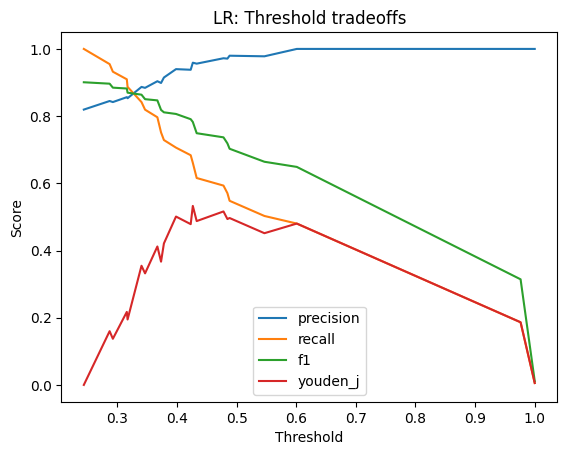

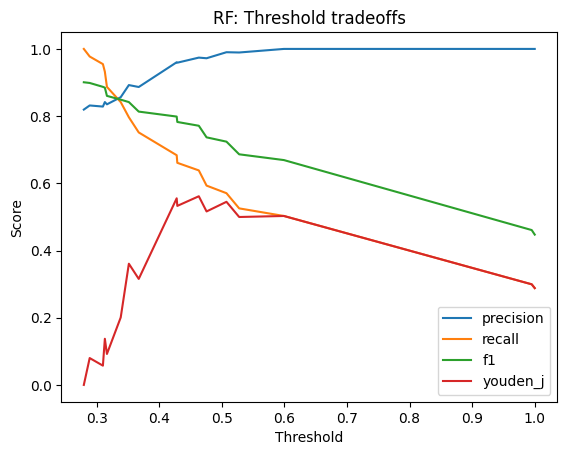

In [49]:
import matplotlib.pyplot as plt

def plot_threshold_curves(df, title):
    d = df.sort_values("threshold")
    plt.figure()
    plt.plot(d["threshold"], d["precision"], label="precision")
    plt.plot(d["threshold"], d["recall"], label="recall")
    plt.plot(d["threshold"], d["f1"], label="f1")
    plt.plot(d["threshold"], d["youden_j"], label="youden_j")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.show()

plot_threshold_curves(lr_thr_table, "LR: Threshold tradeoffs")
plot_threshold_curves(rf_thr_table, "RF: Threshold tradeoffs")

In [50]:
middle_win_flags = []

for _, row in baseline_rows.iterrows():
    times = np.array(row["times"], dtype=float)
    tolls = np.array(row["tolls"], dtype=float)

    # Unique toll levels sorted
    unique_tolls = sorted(np.unique(tolls))

    # Need at least 3 distinct toll levels
    if len(unique_tolls) < 3:
        middle_win_flags.append(False)
        continue

    free_toll = unique_tolls[0]
    max_toll = unique_tolls[-1]
    middle_tolls = unique_tolls[1:-1]

    middle_chosen = False

    for v in vot_grid:
        idx = choose_best_idx(times, tolls, v)
        chosen_toll = tolls[idx]
        if chosen_toll in middle_tolls:
            middle_chosen = True
            break

    middle_win_flags.append(middle_chosen)

middle_win_rate = np.mean(middle_win_flags) * 100

print("Middle-option win rate:",
      round(middle_win_rate,2), "% of baseline OD×hour cases")

Middle-option win rate: 19.05 % of baseline OD×hour cases


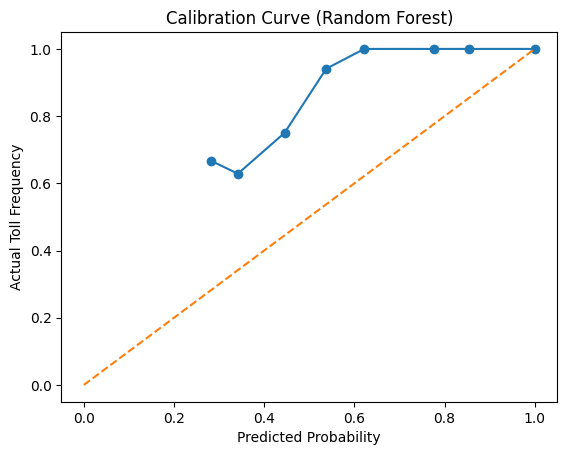

In [51]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob_rf,
    n_bins=10
)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Toll Frequency")
plt.title("Calibration Curve (Random Forest)")
plt.show()

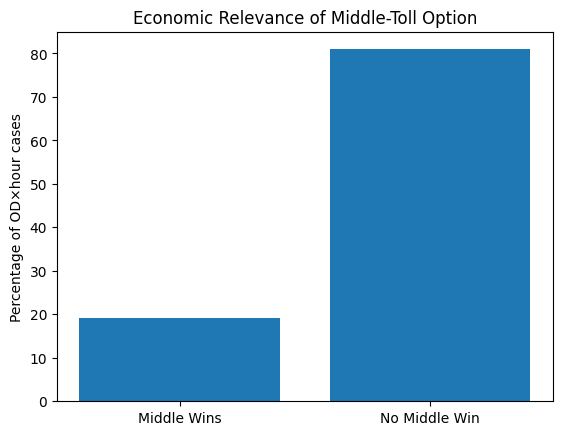

In [52]:
plt.figure()
plt.bar(["Middle Wins", "No Middle Win"], [19.05, 80.95])
plt.ylabel("Percentage of OD×hour cases")
plt.title("Economic Relevance of Middle-Toll Option")
plt.show()